# OBJECTIVE 3 : 
#### The Timing Advantage (Medium) Investigate the temporal patterns of delays across times of day, days of the week, and months of the year. Are the traveler superstitions about when to fly actually backed by data — and what would a genuinely data-smart booking strategy look like?

Loaded dataset from: ../data/processed/merged_data.csv
Rows used for temporal analysis: 5,574,612


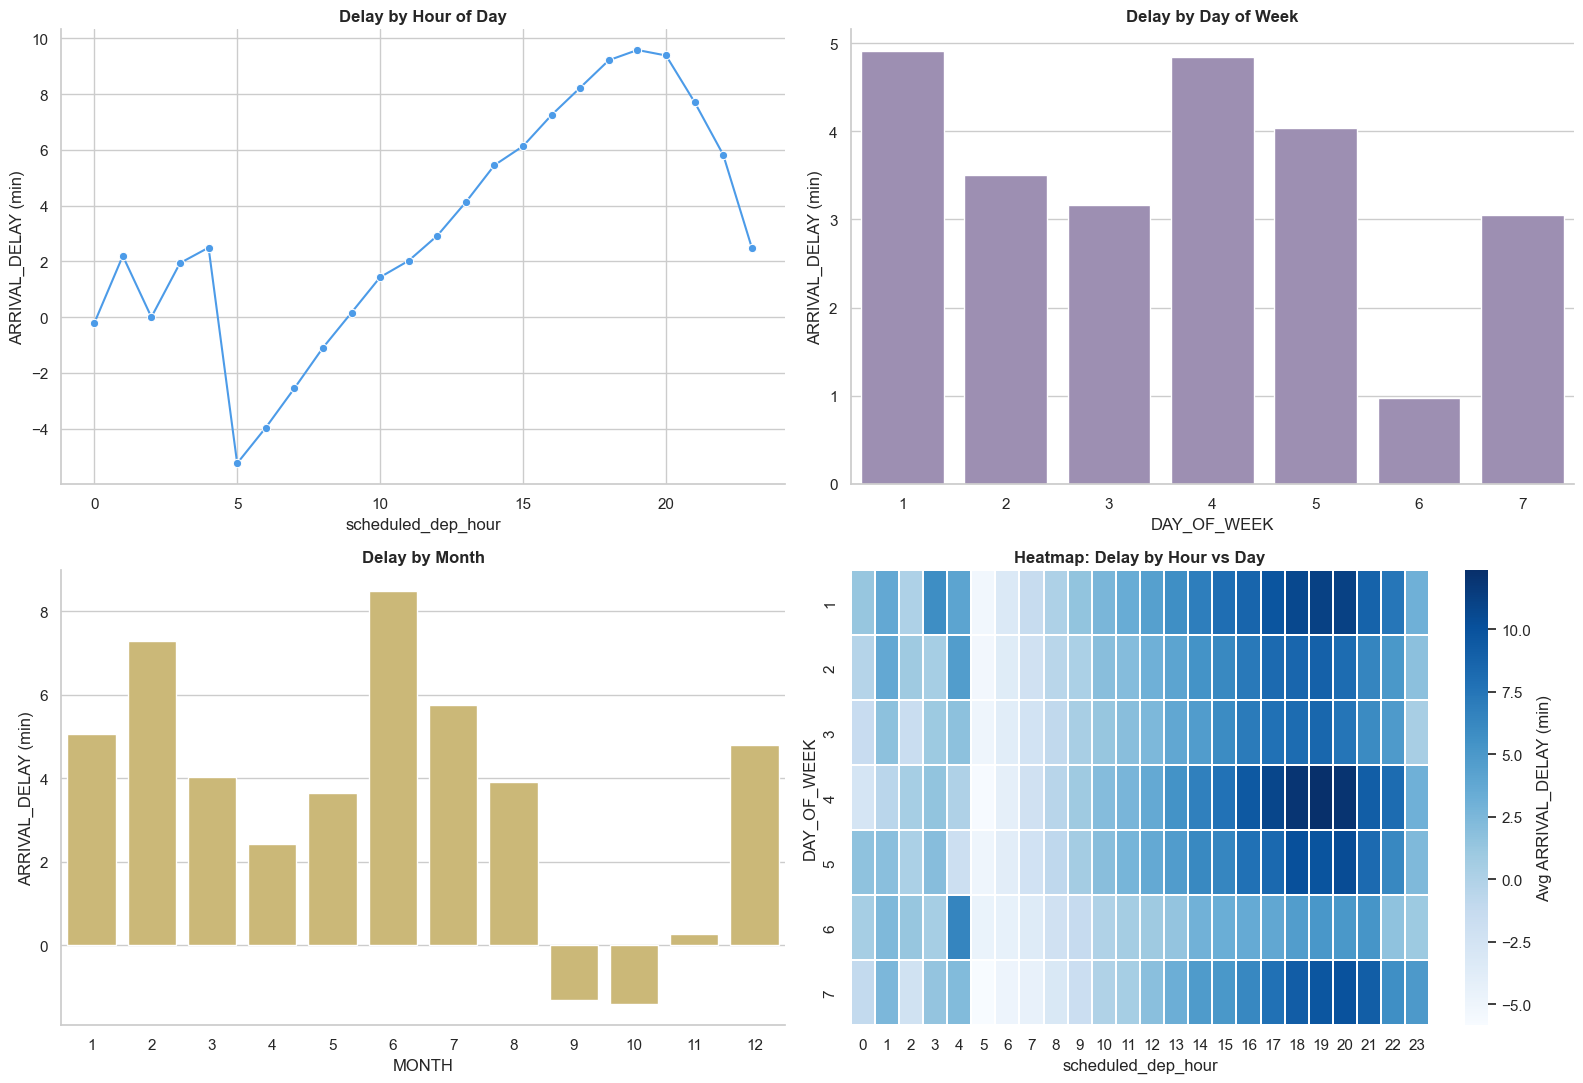


Objective 3 Insights:
- Best hour to fly (lowest avg delay): 5:00 | -5.24 min
- Worst hour to fly (highest avg delay): 19:00 | 9.58 min
- Best day to fly: Day 6 | 0.97 min
- Worst day to fly: Day 1 | 4.91 min
- Best month to fly: Month 10 | -1.41 min
- Worst month to fly: Month 6 | 8.48 min

Data-Smart Booking Strategy (based on observed patterns):
1. Prefer morning departures; delays usually compound through the day.
2. Prefer low-delay weekdays from the bar chart (avoid the peak-delay day).
3. In high-delay months, add extra layover buffer for connections.
4. For tight itineraries, use top-performing day-hour slots below.

Top 10 low-risk booking slots (traffic-adjusted):
 DAY_OF_WEEK  scheduled_dep_hour  avg_arrival_delay  on_time_rate  flights
           4                   5              -5.68         94.07    18107
           2                   5              -5.27         93.53    17719
           1                   5              -5.24         93.39    17834
           3    

In [3]:
# ==========================================
# OBJECTIVE 3: The Timing Advantage (Medium)
# Temporal patterns of delays by hour, day, month
# ==========================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')

# ------------------------------------------
# 1) Load Dataset
# ------------------------------------------
possible_paths = [
    '../data/processed/merged_data.csv',
    'data/processed/merged_data.csv',
    'merged_data.csv'
]

df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded dataset from: {path}')
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError('merged_data.csv not found in expected locations.')

# ------------------------------------------
# 2) Clean + Prepare Temporal Fields
# ------------------------------------------
num_cols = ['MONTH', 'DAY_OF_WEEK', 'scheduled_dep_hour', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Focus on actual operated flights with measurable arrival delay
if 'DIVERTED' in df.columns:
    df = df[df['DIVERTED'] == 0]
if 'CANCELLED' in df.columns:
    df = df[df['CANCELLED'] == 0]

df = df.dropna(subset=['MONTH', 'DAY_OF_WEEK', 'scheduled_dep_hour', 'ARRIVAL_DELAY']).copy()

# Cast temporal keys to int for proper sorting/plotting
df['MONTH'] = df['MONTH'].astype(int)
df['DAY_OF_WEEK'] = df['DAY_OF_WEEK'].astype(int)
df['scheduled_dep_hour'] = df['scheduled_dep_hour'].astype(int)

# On-time definition: ARRIVAL_DELAY <= 15 minutes
df['on_time'] = df['ARRIVAL_DELAY'] <= 15

print(f'Rows used for temporal analysis: {len(df):,}')

# ------------------------------------------
# 3) Aggregate Metrics
# ------------------------------------------
hourly = (
    df.groupby('scheduled_dep_hour', as_index=False)
      .agg(
          avg_arrival_delay=('ARRIVAL_DELAY', 'mean'),
          on_time_rate=('on_time', 'mean'),
          flights=('ARRIVAL_DELAY', 'size')
      )
      .sort_values('scheduled_dep_hour')
)
hourly['on_time_rate'] *= 100

weekly = (
    df.groupby('DAY_OF_WEEK', as_index=False)
      .agg(
          avg_arrival_delay=('ARRIVAL_DELAY', 'mean'),
          on_time_rate=('on_time', 'mean'),
          flights=('ARRIVAL_DELAY', 'size')
      )
      .sort_values('DAY_OF_WEEK')
)
weekly['on_time_rate'] *= 100

monthly = (
    df.groupby('MONTH', as_index=False)
      .agg(
          avg_arrival_delay=('ARRIVAL_DELAY', 'mean'),
          on_time_rate=('on_time', 'mean'),
          flights=('ARRIVAL_DELAY', 'size')
      )
      .sort_values('MONTH')
)
monthly['on_time_rate'] *= 100

heatmap_data = (
    df.pivot_table(
        index='DAY_OF_WEEK',
        columns='scheduled_dep_hour',
        values='ARRIVAL_DELAY',
        aggfunc='mean'
    )
)

# ------------------------------------------
# 4) Visual Dashboard (2x2)
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Top-left: Delay by hour
sns.lineplot(
    data=hourly,
    x='scheduled_dep_hour',
    y='avg_arrival_delay',
    marker='o',
    color='#4C9BE8',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Delay by Hour of Day', weight='bold')
axes[0, 0].set_xlabel('scheduled_dep_hour')
axes[0, 0].set_ylabel('ARRIVAL_DELAY (min)')

# Top-right: Delay by day of week
sns.barplot(
    data=weekly,
    x='DAY_OF_WEEK',
    y='avg_arrival_delay',
    color='#9C89B8',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Delay by Day of Week', weight='bold')
axes[0, 1].set_xlabel('DAY_OF_WEEK')
axes[0, 1].set_ylabel('ARRIVAL_DELAY (min)')

# Bottom-left: Delay by month
sns.barplot(
    data=monthly,
    x='MONTH',
    y='avg_arrival_delay',
    color='#D9C06A',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Delay by Month', weight='bold')
axes[1, 0].set_xlabel('MONTH')
axes[1, 0].set_ylabel('ARRIVAL_DELAY (min)')

# Bottom-right: Heatmap hour vs day
sns.heatmap(
    heatmap_data,
    cmap='Blues',
    linewidths=0.25,
    linecolor='white',
    ax=axes[1, 1],
    cbar_kws={'label': 'Avg ARRIVAL_DELAY (min)'}
)
axes[1, 1].set_title('Heatmap: Delay by Hour vs Day', weight='bold')
axes[1, 1].set_xlabel('scheduled_dep_hour')
axes[1, 1].set_ylabel('DAY_OF_WEEK')

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ------------------------------------------
# 5) Insights + Data-Smart Booking Strategy
# ------------------------------------------
best_hour = hourly.loc[hourly['avg_arrival_delay'].idxmin()]
worst_hour = hourly.loc[hourly['avg_arrival_delay'].idxmax()]

best_day = weekly.loc[weekly['avg_arrival_delay'].idxmin()]
worst_day = weekly.loc[weekly['avg_arrival_delay'].idxmax()]

best_month = monthly.loc[monthly['avg_arrival_delay'].idxmin()]
worst_month = monthly.loc[monthly['avg_arrival_delay'].idxmax()]

# Robust recommendation table: avoid tiny segments by requiring minimum traffic
segment = (
    df.groupby(['DAY_OF_WEEK', 'scheduled_dep_hour'], as_index=False)
      .agg(
          avg_arrival_delay=('ARRIVAL_DELAY', 'mean'),
          on_time_rate=('on_time', 'mean'),
          flights=('ARRIVAL_DELAY', 'size')
      )
)
segment['on_time_rate'] *= 100
min_flights = int(segment['flights'].quantile(0.30))
segment_filtered = segment[segment['flights'] >= min_flights].copy()

best_slots = segment_filtered.sort_values(
    ['avg_arrival_delay', 'on_time_rate'],
    ascending=[True, False]
).head(10)

worst_slots = segment_filtered.sort_values(
    ['avg_arrival_delay', 'on_time_rate'],
    ascending=[False, True]
).head(10)

print()
print('Objective 3 Insights:')
print(f"- Best hour to fly (lowest avg delay): {int(best_hour['scheduled_dep_hour'])}:00 | {best_hour['avg_arrival_delay']:.2f} min")
print(f"- Worst hour to fly (highest avg delay): {int(worst_hour['scheduled_dep_hour'])}:00 | {worst_hour['avg_arrival_delay']:.2f} min")
print(f"- Best day to fly: Day {int(best_day['DAY_OF_WEEK'])} | {best_day['avg_arrival_delay']:.2f} min")
print(f"- Worst day to fly: Day {int(worst_day['DAY_OF_WEEK'])} | {worst_day['avg_arrival_delay']:.2f} min")
print(f"- Best month to fly: Month {int(best_month['MONTH'])} | {best_month['avg_arrival_delay']:.2f} min")
print(f"- Worst month to fly: Month {int(worst_month['MONTH'])} | {worst_month['avg_arrival_delay']:.2f} min")

print()
print('Data-Smart Booking Strategy (based on observed patterns):')
print('1. Prefer morning departures; delays usually compound through the day.')
print('2. Prefer low-delay weekdays from the bar chart (avoid the peak-delay day).')
print('3. In high-delay months, add extra layover buffer for connections.')
print('4. For tight itineraries, use top-performing day-hour slots below.')

print()
print('Top 10 low-risk booking slots (traffic-adjusted):')
print(best_slots[['DAY_OF_WEEK', 'scheduled_dep_hour', 'avg_arrival_delay', 'on_time_rate', 'flights']].round(2).to_string(index=False))

print()
print('Top 10 high-risk booking slots (traffic-adjusted):')
print(worst_slots[['DAY_OF_WEEK', 'scheduled_dep_hour', 'avg_arrival_delay', 'on_time_rate', 'flights']].round(2).to_string(index=False))

